In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Load the serialized data from the directory where they were saved
DATA_DIR = os.path.join("..", "data") # The directory where the serialized data is stored, the ".." represents the parent directory
X = np.load(os.path.join(DATA_DIR, "X_features.npy"))
y = np.load(os.path.join(DATA_DIR, "y_labels.npy"))

print(f"Loaded X shape: {X.shape}") # Confirming the shape of the loaded features is 1440, 20, 125 representing 1440 samples, 20 MFCCs coefficients, and 125 time frames
print(f"Loaded y shape: {y.shape}") # Confirming the shape of the loaded labels 1440 representing 1440 samples


Loaded X shape: (1440, 20, 125)
Loaded y shape: (1440,)


In [2]:
# 1. Label Encoding (String -> Integer -> One-Hot)
label_encoder = LabelEncoder() # Initialize the LabelEncoder to convert string labels into integers. The variable label_encoder is an instance of the LabelEncoder class, which will be used to fit and transform the labels.
y_encoded = label_encoder.fit_transform(y) # Fit the LabelEncoder to the labels and transform them into integer-encoded labels. The fit_transform method learns the mapping from string labels to integers and applies this mapping to the labels, resulting in an array of integer-encoded labels. It is a combination of the fit (scans the array discovers all 8 unique values and alphabetizes them) and transform (It replaces every string label with its corresponding new integer ID)  methods, which is a common practice in machine learning to prepare categorical data for modeling.
y_categorical = to_categorical(y_encoded) # Convert the integer-encoded labels into one-hot encoded vectors. It builds a matrix where each row corresponds to a sample and each column corresponds to a class. The value is 1 if the sample belongs to that class and 0 otherwise. This is a common practice in machine learning to prepare categorical data for modeling, especially for multi-class classification problems to prevent the model from assuming an ordinal relationship between classes.

# By the end of this step, we have transformed the original string labels into a format suitable for training a machine learning model. The labels are now represented as one-hot encoded vectors, which can be used as the target variable in our model training process. The shape is now (1440, 8) representing 1440 samples and 8 classes (emotions).
# 2. Train/Test Split (80/20)
# implemting the stratify=y_encoded guarantees the exact same proportion of emotions in both sets. This is especially useful here in the RAVDESS dataset, where the distribution of emotions is not uniform. For example, if we have 100 samples of emotion A and 50 samples of emotion B, without stratification, we might end up with a training set that has 80 samples of emotion A and only 10 samples of emotion B. This would lead to a model that is biased towards emotion A and performs poorly on emotion B. By using stratification, we ensure that both the training and testing sets have the same proportion of each emotion, which helps the model learn to recognize all emotions more effectively.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"X_train shape: {X_train.shape}") # Confirming the shape of the training features is 1152, 20, 125 representing 1152 samples, 20 MFCCs coefficients, and 125 time frames corresponding to 80% of the original dataset
print(f"X_test shape: {X_test.shape}") # Confirming the shape of the testing features is 288, 20, 125 representing 288 samples, 20 MFCCs coefficients, and 125 time frames corresponding to 20% of the original dataset
print(f"y_train shape: {y_train.shape}") # Confirming the shape of the training labels is 1152, 8 representing 1152 samples and 8 classes
print(f"y_test shape: {y_test.shape}") # Confirming the shape of the testing labels is 288, 8 representing 288 samples and 8 classes

X_train shape: (1152, 20, 125)
X_test shape: (288, 20, 125)
y_train shape: (1152, 8)
y_test shape: (288, 8)


In [ ]:
# 3. Feature Scaling (Prevent Data Leakage by fitting strictly on X_train)
scaler = StandardScaler()

# Store original dimensions
train_shape = X_train.shape
test_shape = X_test.shape

# Scikit-learn scalers expect 2D arrays, so we flatten, scale, and reshape back to 3D
X_train_scaled = scaler.fit_transform(X_train.reshape(train_shape[0], -1)).reshape(train_shape) # It is  a three chain command of reshaping the array sent to the fit_transform method, which is a common practice in machine learning to prepare data for modeling. The reshape method is used to flatten the 3D array into a 2D array, where each row corresponds to a sample and each column corresponds to a feature. The fit_transform method is then applied to this 2D array, which standardizes the features by removing the mean and scaling to unit variance. Finally, the reshape method is used again to convert the scaled 2D array back into its original 3D shape, so that it can be used as input for the model.
X_test_scaled = scaler.transform(X_test.reshape(test_shape[0], -1)).reshape(test_shape) # The same process is applied to the testing set, but only the transform method is used, as we want to apply the same scaling parameters learned from the training set to the testing set. This ensures that the model is evaluated on data that has been scaled in the same way as the training data, which is important for maintaining consistency and preventing data leakage.

# 4. Add the Channel Dimension (Mono Audio = 1 Channel)
X_train_final = np.expand_dims(X_train_scaled, axis=-1) # As only 4D tensors are accepted by CNNs, we need to add a channel dimension to the input data. The np.expand_dims function is used to add a new axis at the end of the array, effectively converting the 3D array into a 4D array. This is necessary because CNNs expect input data to have a specific shape, which includes a channel dimension. In this case, since we are working with mono audio data, we add a channel dimension of size 1, indicating that there is only one channel in the input data. The additionel dimension was added at the end of the array, which is specified by axis=-1. This means that the new dimension will be added as the last dimension of the array, resulting in a shape of (num_samples, num_features, num_time_frames, 1). This is a common practice in deep learning when working with data that has a single channel, such as grayscale images or mono audio signals.
X_test_final = np.expand_dims(X_test_scaled, axis=-1) # Same expansion was performed for the testing set, ensuring that both the training and testing data have the same shape and can be used as input for the CNN model.

print("\n--- DEEP LEARNING TENSORS READY ---")
print(f"Final X_train shape for CNN: {X_train_final.shape}") # Final Conformation of the shape of the training features is 1152, 20, 125, 1 representing 1152 samples, 20 MFCCs coefficients, 125 time frames, and 1 channel corresponding to 80% of the original dataset. It is very vital to constantly check the shape of the data at each step of the preprocessing pipeline to ensure that it is in the correct format for the model. This helps to prevent errors and ensures that the model can learn effectively from the data.
print(f"Final X_test shape for CNN: {X_test_final.shape}") # Same confirmation was performed for the testing set, ensuring that both the training and testing data have the same shape and can be used as input for the CNN model.


--- DEEP LEARNING TENSORS READY ---
Final X_train shape for CNN: (1152, 20, 125, 1)
Final X_test shape for CNN: (288, 20, 125, 1)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

input_shape = (20, 125, 1)
model = Sequential()

# Block 1: Added padding='same'
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block 2: Added padding='same'
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block 3: Added padding='same'
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Flattening & Classification
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 20, 125, 32)       320       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 10, 62, 32)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 10, 62, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 10, 62, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 5, 31, 64)         0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 5, 31, 64)       

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_cnn_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True,
    verbose=1
)

# Start training
print("--- STARTING MODEL TRAINING ---")
history = model.fit(
    X_train_final, y_train,
    validation_data=(X_test_final, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)
print("--- TRAINING COMPLETE ---")

--- STARTING MODEL TRAINING ---
Epoch 1/50


36/36 [==============================] - ETA: 0s - loss: 1.9879 - accuracy: 0.2170
Epoch 1: val_accuracy improved from -inf to 0.28819, saving model to best_cnn_model.keras
36/36 [==============================] - 11s 151ms/step - loss: 1.9879 - accuracy: 0.2170 - val_loss: 1.8474 - val_accuracy: 0.2882
Epoch 2/50
36/36 [==============================] - ETA: 0s - loss: 1.7436 - accuracy: 0.3273
Epoch 2: val_accuracy improved from 0.28819 to 0.39236, saving model to best_cnn_model.keras
36/36 [==============================] - 5s 151ms/step - loss: 1.7436 - accuracy: 0.3273 - val_loss: 1.6728 - val_accuracy: 0.3924
Epoch 3/50
36/36 [==============================] - ETA: 0s - loss: 1.5723 - accuracy: 0.4045
Epoch 3: val_accuracy did not improve from 0.39236
36/36 [==============================] - 4s 124ms/step - loss: 1.5723 - accuracy: 0.4045 - val_loss: 1.5639 - val_accuracy: 0.3924
Epoch 4/50
36/36 [==============================] - ETA:

--- GENERATING PREDICTIONS ---
9/9 [==============================] - 0s 21ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       angry       0.80      0.84      0.82        38
        calm       0.73      0.71      0.72        38
     disgust       0.61      0.58      0.59        38
     fearful       0.61      0.56      0.59        39
       happy       0.53      0.54      0.53        39
     neutral       0.48      0.58      0.52        19
         sad       0.61      0.61      0.61        38
   surprised       0.82      0.79      0.81        39

    accuracy                           0.66       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.66      0.66      0.66       288



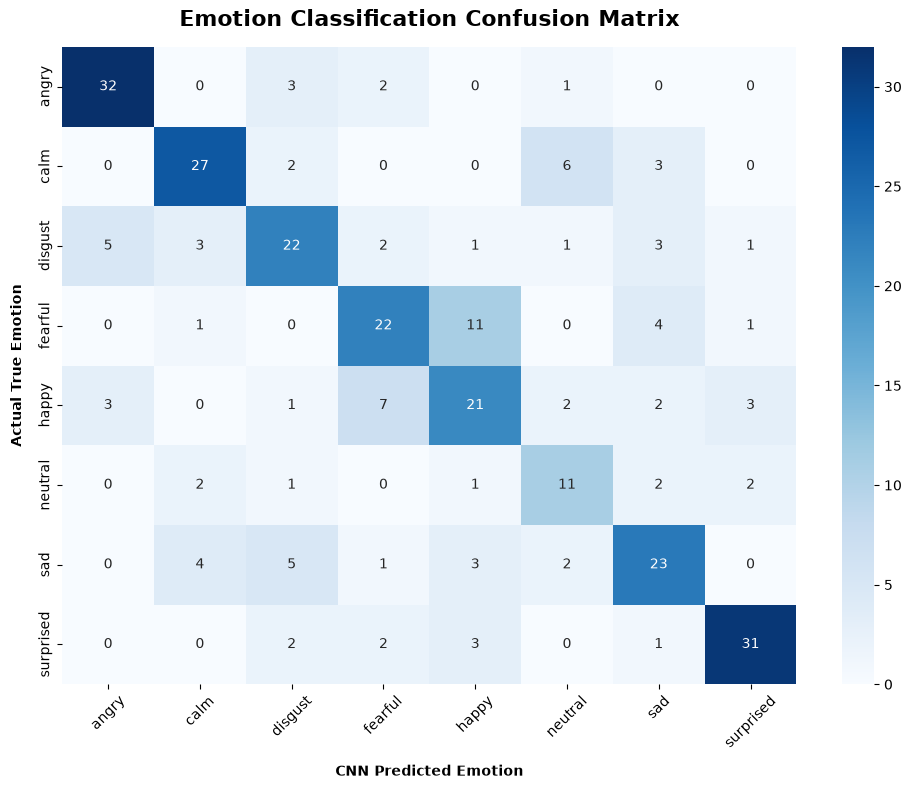

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predict the test set
print("--- GENERATING PREDICTIONS ---")
y_pred_probs = model.predict(X_test_final)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get the actual string labels for the axes
emotion_labels = label_encoder.classes_

# 1. Classification Report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

# 2. Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Emotion Classification Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual True Emotion', fontweight='bold', labelpad=10)
plt.xlabel('CNN Predicted Emotion', fontweight='bold', labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()